# Évaluation comparative + Étude de robustesse — YOLO11n vs RF-DETR-S

**Plateforme :** Google Colab (T4 GPU recommandé)

Ce notebook regroupe :
1. Exploration du dataset ASL
2. Évaluation comparative sur le test set (mAP, P, R, F1, temps, taille)
3. Étude de robustesse sur 5 conditions dégradées (luminosité, bruit)

**Prérequis :** uploader les poids fine-tunés `best.pt` (YOLO) et `checkpoint_best_total.pth` (RF-DETR) générés par les notebooks 02 et 03.

## 1. Setup

In [1]:
!pip install -q ultralytics rfdetr roboflow supervision matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.2/253.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 120.9 MB/s eta 0:00:00


In [7]:
from google.colab import files
import os

print('Upload best.pt (YOLO) puis checkpoint_best_total.pth (RF-DETR)')
uploaded = files.upload()
for fname in uploaded:
    print(f'  uploaded: {fname} ({os.path.getsize(fname)/1024/1024:.1f} MB)')

Upload best.pt (YOLO) puis checkpoint_best_total.pth (RF-DETR)


Saving checkpoint_best_total.pth to checkpoint_best_total.pth
  uploaded: checkpoint_best_total.pth (121.8 MB)


In [3]:
import os, glob
from roboflow import Roboflow

API_KEY = os.environ.get('ROBOFLOW_API_KEY', '01ppKST0VVzBcfnAElsw')
rf = Roboflow(api_key=API_KEY)
project = rf.workspace('david-lee-d0rhs').project('american-sign-language-letters')
version = project.version(6)
ds_yolo = version.download('yolov11', location='ds_yolo')
ds_coco = version.download('coco', location='ds_coco')
print('YOLO format:', ds_yolo.location)
print('COCO format:', ds_coco.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ds_yolo in yolov11:: 100%|██████████| 1452/1452 [00:00<00:00, 1600.04it/s]


Extracting Dataset Version Zip to ds_coco in coco:: 100%|██████████| 728/728 [00:00<00:00, 1922.70it/s]

YOLO format: /content/ds_yolo
COCO format: /content/ds_coco


## 2. Exploration du dataset

Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Splits: {'train': {'images': 504, 'labels': 504}, 'val': {'images': 144, 'labels': 144}, 'test': {'images': 72, 'labels': 72}}


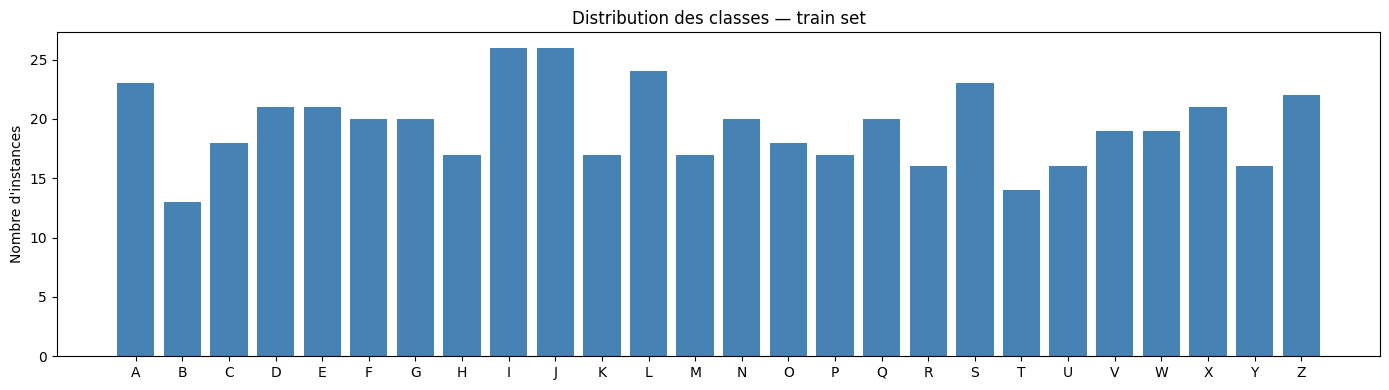

In [4]:
import json, glob
import yaml
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

with open(Path(ds_yolo.location)/'data.yaml') as f:
    cfg = yaml.safe_load(f)
classes = cfg['names']
print(f'Classes ({cfg["nc"]}):', classes)

splits = {'train': 'train', 'val': 'valid', 'test': 'test'}
stats = {}
for split, folder in splits.items():
    imgs = glob.glob(f'{ds_yolo.location}/{folder}/images/*.jpg')
    lbls = glob.glob(f'{ds_yolo.location}/{folder}/labels/*.txt')
    stats[split] = {'images': len(imgs), 'labels': len(lbls)}

print('Splits:', stats)

# Distribution des classes (train)
counter = Counter()
for lbl in glob.glob(f'{ds_yolo.location}/train/labels/*.txt'):
    with open(lbl) as f:
        for line in f:
            cls = int(line.split()[0])
            counter[classes[cls]] += 1

fig, ax = plt.subplots(figsize=(14, 4))
items = sorted(counter.items())
ax.bar([k for k,_ in items], [v for _,v in items], color='steelblue')
ax.set_title('Distribution des classes — train set')
ax.set_ylabel('Nombre d\'instances')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

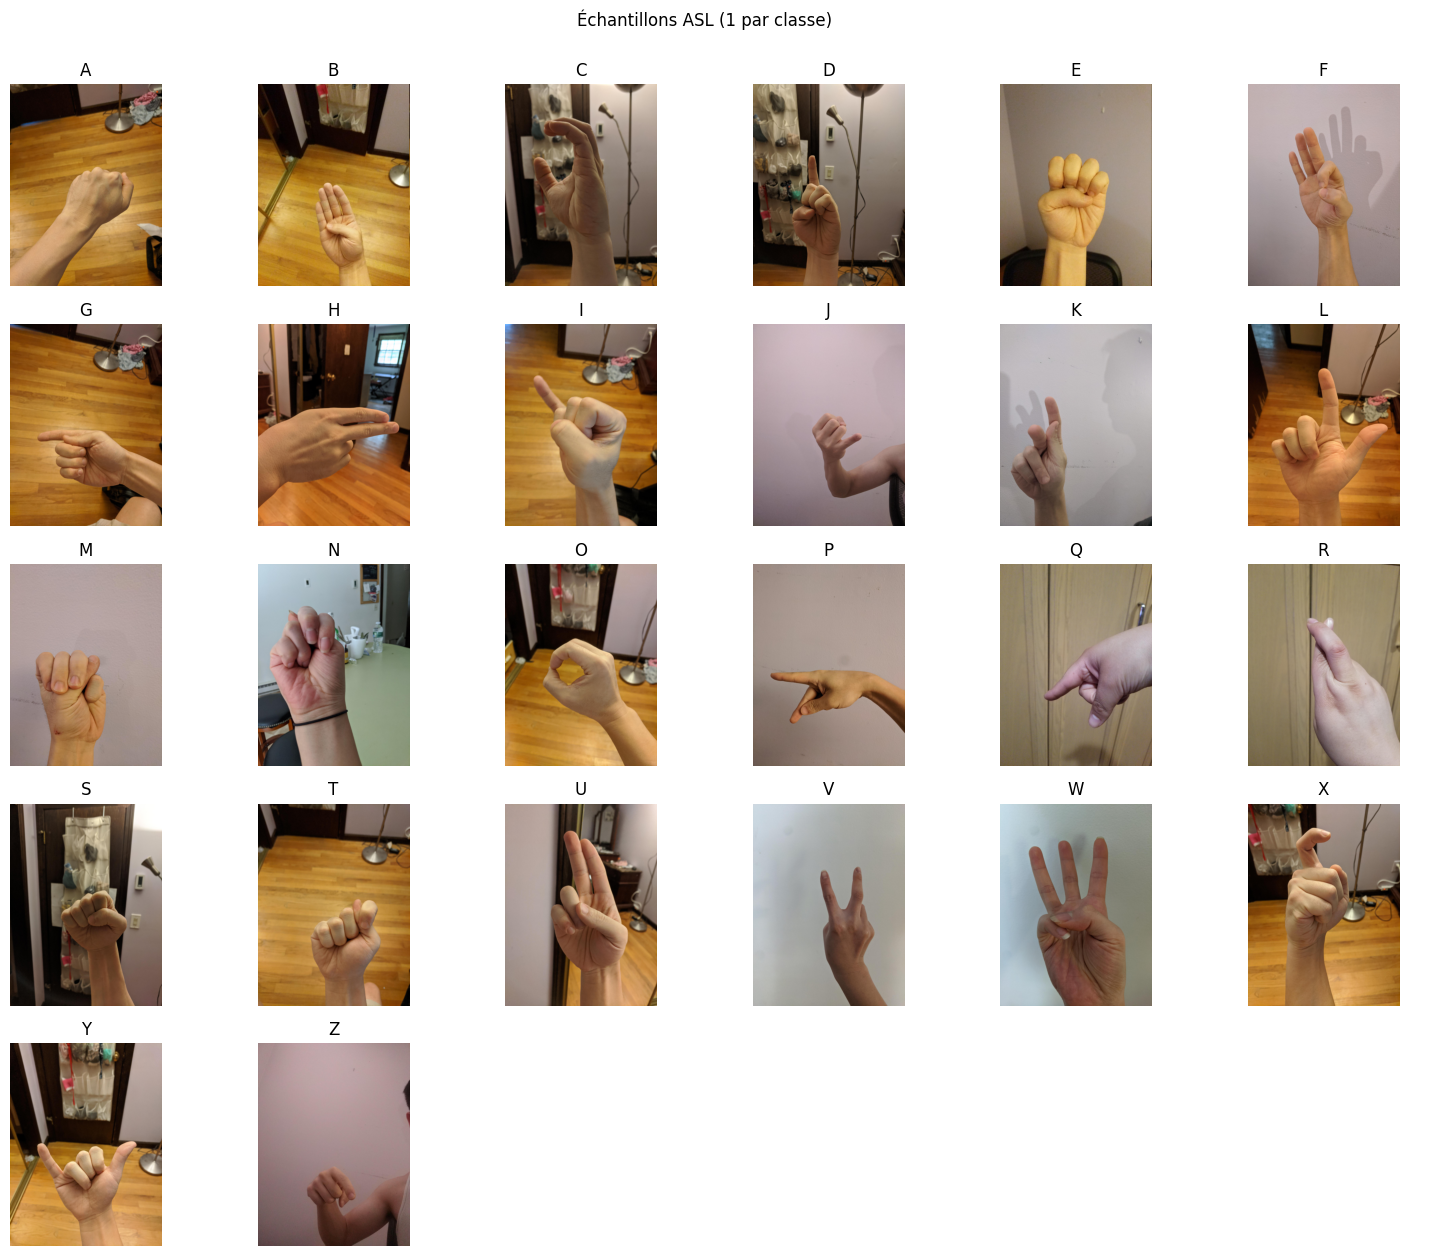

In [5]:
# Grille d'échantillons (1 par classe)
import cv2
import numpy as np

samples = {}
for img_path in glob.glob(f'{ds_yolo.location}/train/images/*.jpg'):
    name = Path(img_path).stem
    lbl = Path(ds_yolo.location)/'train'/'labels'/(name + '.txt')
    if not lbl.exists():
        continue
    with open(lbl) as f:
        first = f.readline().split()
        if not first:
            continue
        cls = classes[int(first[0])]
    if cls not in samples:
        samples[cls] = img_path
    if len(samples) == len(classes):
        break

rows = (len(classes)+5)//6
fig, axes = plt.subplots(rows, 6, figsize=(15, 2.5*rows))
axes = axes.flatten()
for i, cls in enumerate(sorted(samples.keys())):
    img = cv2.cvtColor(cv2.imread(samples[cls]), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
for j in range(len(samples), len(axes)):
    axes[j].axis('off')
plt.suptitle('Échantillons ASL (1 par classe)', y=1.001)
plt.tight_layout()
plt.savefig('fig_samples_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Chargement des modèles fine-tunés

In [8]:
from ultralytics import YOLO
from rfdetr import RFDETRSmall

yolo_model = YOLO('best.pt')
rfdetr_model = RFDETRSmall(pretrain_weights='checkpoint_best_total.pth')
print('Modèles chargés.')

[2026-05-08 23:19:57] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-08 23:19:57] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-08 23:19:58] [WARNING] rf-detr - Checkpoint has 27 classes but model is configured for 90. Using checkpoint class count (27). Pass num_classes=27 to suppress this warning.


Modèles chargés.


## 4. Évaluation comparative — métriques principales

In [10]:
import time

# YOLO via Ultralytics
yolo_metrics = yolo_model.val(data=f'{ds_yolo.location}/data.yaml', split='test', plots=True, verbose=False)
yolo_summary = {
    'mAP50': float(yolo_metrics.box.map50),
    'mAP50-95': float(yolo_metrics.box.map),
    'precision': float(yolo_metrics.box.mp),
    'recall': float(yolo_metrics.box.mr),
}
f1 = 2*yolo_summary['precision']*yolo_summary['recall']/(yolo_summary['precision']+yolo_summary['recall']+1e-12)
yolo_summary['F1'] = float(f1)
print('YOLO :', yolo_summary)

# RF-DETR : on ne tente plus .evaluate(), on prépare juste un dict vide
# que la cellule 13 (supervision) remplira.
rfdetr_eval = None
rfdetr_summary = {}
print('RF-DETR : éval déléguée à la cellule 13 via supervision')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3242.6±594.2 MB/s, size: 222.8 KB)
val: Scanning /content/ds_yolo/test/labels.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 21.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5it/s 3.4s
                   all         72         72      0.879      0.755      0.904      0.875
Speed: 6.6ms preprocess, 5.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val-2
YOLO : {'mAP50': 0.9041833751044278, 'mAP50-95': 0.8753362312030074, 'precision': 0.8785295125987806, 'recall': 0.7546430883769389, 'F1': 0.8118875178549254}
RF-DETR : éval déléguée à la cellule 13 via supervision


In [11]:
# Adaptation : extraire les métriques de RF-DETR (format COCO)
# Suivant la version de rfdetr, evaluate() renvoie un dict ou un objet.
# Fallback robuste:
rfdetr_summary = {}
if isinstance(rfdetr_eval, dict):
    rfdetr_summary['mAP50']    = float(rfdetr_eval.get('map50', rfdetr_eval.get('AP50', 0)))
    rfdetr_summary['mAP50-95'] = float(rfdetr_eval.get('map', rfdetr_eval.get('AP', 0)))
else:
    # Si retour non-dict, on évalue manuellement avec supervision/pycocotools
    print('Format inhabituel, évaluation manuelle nécessaire — voir cellule suivante')

print('RF-DETR summary:', rfdetr_summary)

Format inhabituel, évaluation manuelle nécessaire — voir cellule suivante
RF-DETR summary: {}


In [13]:
import supervision as sv
from PIL import Image
import json, glob
from pathlib import Path
import numpy as np

def evaluate_with_supervision(detector_predict_fn, coco_dir, split='test'):
    """Évalue avec mAP via supervision (nouvelle API .update/.compute)."""
    ann_file = Path(coco_dir)/split/'_annotations.coco.json'
    with open(ann_file) as f:
        coco = json.load(f)
    cat_id_to_idx = {c['id']: i for i, c in enumerate(sorted(coco['categories'], key=lambda x: x['id']))}
    img_id_to_file = {im['id']: im['file_name'] for im in coco['images']}
    img_id_to_anns = {}
    for a in coco['annotations']:
        img_id_to_anns.setdefault(a['image_id'], []).append(a)

    metric = sv.metrics.MeanAveragePrecision()
    for img_id, fname in img_id_to_file.items():
        img_path = Path(coco_dir)/split/fname
        if not img_path.exists():
            continue
        img = Image.open(img_path).convert('RGB')
        anns = img_id_to_anns.get(img_id, [])
        if anns:
            xyxy, cls = [], []
            for a in anns:
                x, y, w, h = a['bbox']
                xyxy.append([x, y, x+w, y+h])
                cls.append(cat_id_to_idx[a['category_id']])
            tgt = sv.Detections(xyxy=np.array(xyxy), class_id=np.array(cls))
        else:
            tgt = sv.Detections.empty()
        pred = detector_predict_fn(img)
        metric.update([pred], [tgt])
    return metric.compute()
def rfdetr_predict(img):
    return rfdetr_model.predict(img, threshold=0.001)

rfdetr_map = evaluate_with_supervision(rfdetr_predict, ds_coco.location, 'test')
print('RF-DETR (supervision) — mAP50:', rfdetr_map.map50, ' mAP50-95:', rfdetr_map.map50_95)
rfdetr_summary['mAP50'] = float(rfdetr_map.map50)
rfdetr_summary['mAP50-95'] = float(rfdetr_map.map50_95)

RF-DETR (supervision) — mAP50: 0.9013364459250592  mAP50-95: 0.8811640157098205


## 5. Temps d'inférence et taille des modèles

In [14]:
import time
from PIL import Image

test_imgs = sorted(glob.glob(f'{ds_coco.location}/test/*.jpg'))[:50]
imgs_pil = [Image.open(p).convert('RGB') for p in test_imgs]

def bench(predict_fn, imgs, warmup=2):
    for img in imgs[:warmup]:
        predict_fn(img)
    start = time.perf_counter()
    for img in imgs:
        predict_fn(img)
    return (time.perf_counter()-start)*1000/len(imgs)  # ms/img

ms_yolo = bench(lambda i: yolo_model.predict(i, verbose=False), imgs_pil)
ms_rfdetr = bench(lambda i: rfdetr_model.predict(i, threshold=0.25), imgs_pil)

yolo_summary['inference_ms'] = ms_yolo
yolo_summary['fps'] = 1000/ms_yolo
rfdetr_summary['inference_ms'] = ms_rfdetr
rfdetr_summary['fps'] = 1000/ms_rfdetr
yolo_summary['size_MB'] = os.path.getsize('best.pt')/1024/1024
rfdetr_summary['size_MB'] = os.path.getsize('checkpoint_best_total.pth')/1024/1024

print(f'YOLO    : {ms_yolo:.1f} ms/img  ({1000/ms_yolo:.1f} FPS)  -  {yolo_summary["size_MB"]:.1f} MB')
print(f'RF-DETR : {ms_rfdetr:.1f} ms/img  ({1000/ms_rfdetr:.1f} FPS)  -  {rfdetr_summary["size_MB"]:.1f} MB')

YOLO    : 36.4 ms/img  (27.5 FPS)  -  5.2 MB
RF-DETR : 132.8 ms/img  (7.5 FPS)  -  121.8 MB


## 6. Tableau récapitulatif & figure comparative

              YOLO11n  RF-DETR-S
mAP50          0.9042     0.9013
mAP50-95       0.8753     0.8812
precision      0.8785        NaN
recall         0.7546        NaN
F1             0.8119        NaN
inference_ms  36.3521   132.7967
fps           27.5087     7.5303
size_MB        5.2147   121.8216


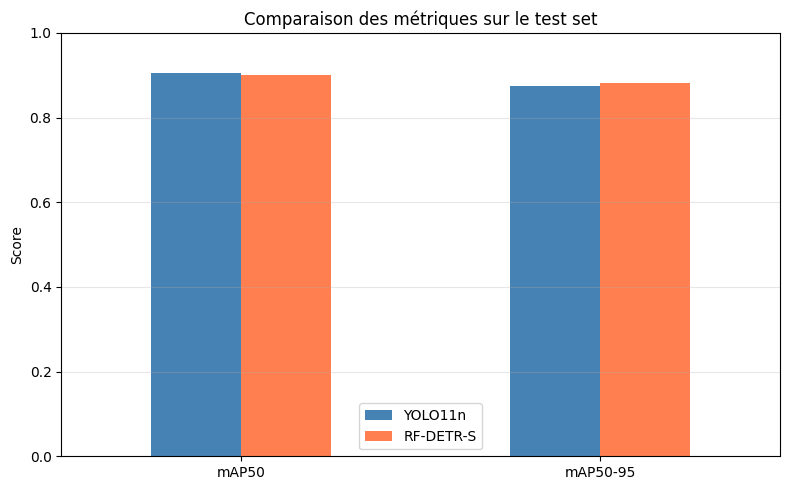

In [15]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({'YOLO11n': yolo_summary, 'RF-DETR-S': rfdetr_summary})
print(df.round(4))
df.to_csv('comparison_summary.csv')

# Figure : barres comparatives
metrics_to_plot = ['mAP50', 'mAP50-95', 'precision', 'recall', 'F1']
metrics_to_plot = [m for m in metrics_to_plot if m in df.index and not df.loc[m].isna().any()]

fig, ax = plt.subplots(figsize=(8, 5))
df.loc[metrics_to_plot].plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Comparaison des métriques sur le test set')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Étude de robustesse

5 conditions dégradées générées sur le test set :
- Luminosité : sombre (γ=0.5), peu sombre (γ=0.75), clair (γ=1.5)
- Bruit gaussien : σ=15 (modéré), σ=35 (fort)

In [16]:
import cv2
import shutil
from pathlib import Path

def adjust_gamma(image, gamma):
    inv = 1.0 / max(gamma, 1e-3)
    table = np.array([((i/255.0)**inv)*255 for i in range(256)]).astype('uint8')
    return cv2.LUT(image, table)

def add_gaussian_noise(image, sigma):
    noise = np.random.normal(0, sigma, image.shape).astype(np.float32)
    return np.clip(image.astype(np.float32)+noise, 0, 255).astype(np.uint8)

CONDITIONS = {
    'lum_dark':   lambda i: adjust_gamma(i, 0.5),
    'lum_dim':    lambda i: adjust_gamma(i, 0.75),
    'lum_bright': lambda i: adjust_gamma(i, 1.5),
    'noise_med':  lambda i: add_gaussian_noise(i, 15),
    'noise_high': lambda i: add_gaussian_noise(i, 35),
}

# Générer les variantes au format YOLO
src_img_dir = Path(ds_yolo.location)/'test'/'images'
src_lbl_dir = Path(ds_yolo.location)/'test'/'labels'
src_imgs = sorted(src_img_dir.glob('*.jpg')) + sorted(src_img_dir.glob('*.png'))

robust_dirs = {}
for cond_name, fn in CONDITIONS.items():
    out_dir = Path(f'robustness/{cond_name}')
    (out_dir/'images').mkdir(parents=True, exist_ok=True)
    (out_dir/'labels').mkdir(parents=True, exist_ok=True)
    for ip in src_imgs:
        img = cv2.imread(str(ip))
        if img is None: continue
        cv2.imwrite(str(out_dir/'images'/ip.name), fn(img))
        lp = src_lbl_dir/(ip.stem+'.txt')
        if lp.exists():
            shutil.copy(lp, out_dir/'labels'/lp.name)
    robust_dirs[cond_name] = out_dir
    print(f'  ✓ {cond_name}')

  ✓ lum_dark
  ✓ lum_dim
  ✓ lum_bright
  ✓ noise_med
  ✓ noise_high


In [17]:
# data.yaml par condition
import yaml

with open(f'{ds_yolo.location}/data.yaml') as f:
    base_cfg = yaml.safe_load(f)

yaml_paths = {}
for cond_name, d in robust_dirs.items():
    cfg = dict(base_cfg)
    cfg['test'] = str((d/'images').resolve())
    yp = f'data_{cond_name}.yaml'
    with open(yp, 'w') as f:
        yaml.safe_dump(cfg, f)
    yaml_paths[cond_name] = yp

In [22]:
import yaml
from pathlib import Path

ds_root = Path(ds_yolo.location).resolve()

yaml_paths = {}
for cond_name, d in robust_dirs.items():
    cfg = {
        'path': str(d.resolve()),
        'train': str((ds_root / 'train'  / 'images').resolve()),
        'val':   str((ds_root / 'valid'  / 'images').resolve()),
        'test':  str((d / 'images').resolve()),
        'nc':    base_cfg['nc'],
        'names': base_cfg['names'],
    }
    yp = f'data_{cond_name}.yaml'
    with open(yp, 'w') as f:
        yaml.safe_dump(cfg, f)
    yaml_paths[cond_name] = yp

print('Yaml paths créés:', list(yaml_paths.keys()))

Yaml paths créés: ['lum_dark', 'lum_dim', 'lum_bright', 'noise_med', 'noise_high']


In [26]:
yolo_robust = {}
for cond_name, yp in yaml_paths.items():
    print(f'  YOLO sur {cond_name}...')
    m = yolo_model.val(data=yp, split='test', plots=False, verbose=False)
    yolo_robust[cond_name] = {
        'mAP50': float(m.box.map50),
        'mAP50-95': float(m.box.map),
    }
yolo_robust['baseline'] = {
    'mAP50':    yolo_summary['mAP50'],
    'mAP50-95': yolo_summary['mAP50-95'],
}
print(yolo_robust)


  YOLO sur lum_dark...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2092.2±804.7 MB/s, size: 367.8 KB)
val: Scanning /content/robustness/lum_dark/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 2.3Kit/s 0.0s
val: New cache created: /content/robustness/lum_dark/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.6it/s 1.4s
                   all         72         72      0.804      0.814      0.873      0.843
Speed: 1.2ms preprocess, 3.9ms inference, 0.0ms loss, 1.7ms postprocess per image
  YOLO sur lum_dim...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1991.2±1313.9 MB/s, size: 324.2 KB)
val: Scanning /content/robustness/lum_dim/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 2.3Kit/s 0.0s
v

In [27]:
# Évaluation RF-DETR sur chaque condition (via supervision sur images dégradées)
# Réutilise les annotations COCO du test set, mais en pointant sur les images dégradées.
import shutil

rfdetr_robust = {}
for cond_name, d in robust_dirs.items():
    # Crée un mini-dataset COCO en copiant le _annotations.coco.json original
    out = Path(f'robustness_coco/{cond_name}/test')
    out.mkdir(parents=True, exist_ok=True)
    # Copier les images dégradées
    for ip in (d/'images').glob('*'):
        shutil.copy(ip, out/ip.name)
    # Copier le json d'annotations
    shutil.copy(Path(ds_coco.location)/'test'/'_annotations.coco.json',
                out/'_annotations.coco.json')

    # Évaluer
    print(f'  RF-DETR sur {cond_name}...')
    map_obj = evaluate_with_supervision(rfdetr_predict, Path(out).parent, 'test')
    rfdetr_robust[cond_name] = {
        'mAP50': float(map_obj.map50),
        'mAP50-95': float(map_obj.map50_95),
    }
rfdetr_robust['baseline'] = {'mAP50': rfdetr_summary['mAP50'], 'mAP50-95': rfdetr_summary['mAP50-95']}
print(rfdetr_robust)

  RF-DETR sur lum_dark...
  RF-DETR sur lum_dim...
  RF-DETR sur lum_bright...
  RF-DETR sur noise_med...
  RF-DETR sur noise_high...
{'lum_dark': {'mAP50': 0.8945305057362843, 'mAP50-95': 0.8777586723705291}, 'lum_dim': {'mAP50': 0.8937056653864094, 'mAP50-95': 0.8784326539046712}, 'lum_bright': {'mAP50': 0.9081138024516736, 'mAP50-95': 0.8907382553731562}, 'noise_med': {'mAP50': 0.9023451026064866, 'mAP50-95': 0.8853272700259381}, 'noise_high': {'mAP50': 0.8918666356623705, 'mAP50-95': 0.8646089182706582}, 'baseline': {'mAP50': 0.9013364459250592, 'mAP50-95': 0.8811640157098205}}


In [28]:
# Tableau comparatif de la chute relative
rows = []
for cond in ['baseline', 'lum_bright', 'lum_dim', 'lum_dark', 'noise_med', 'noise_high']:
    if cond in yolo_robust and cond in rfdetr_robust:
        ymap = yolo_robust[cond]['mAP50']
        rmap = rfdetr_robust[cond]['mAP50']
        ydrop = (ymap - yolo_robust['baseline']['mAP50'])/yolo_robust['baseline']['mAP50']*100 if cond != 'baseline' else 0
        rdrop = (rmap - rfdetr_robust['baseline']['mAP50'])/rfdetr_robust['baseline']['mAP50']*100 if cond != 'baseline' else 0
        rows.append({'Condition': cond, 'YOLO mAP50': ymap, 'YOLO Δ%': ydrop,
                     'RF-DETR mAP50': rmap, 'RF-DETR Δ%': rdrop})
df_rob = pd.DataFrame(rows)
print(df_rob.round(3))
df_rob.to_csv('robustness_summary.csv', index=False)

    Condition  YOLO mAP50  YOLO Δ%  RF-DETR mAP50  RF-DETR Δ%
0    baseline       0.904    0.000          0.901       0.000
1  lum_bright       0.916    1.320          0.908       0.752
2     lum_dim       0.895   -1.047          0.894      -0.847
3    lum_dark       0.873   -3.489          0.895      -0.755
4   noise_med       0.885   -2.105          0.902       0.112
5  noise_high       0.210  -76.769          0.892      -1.051


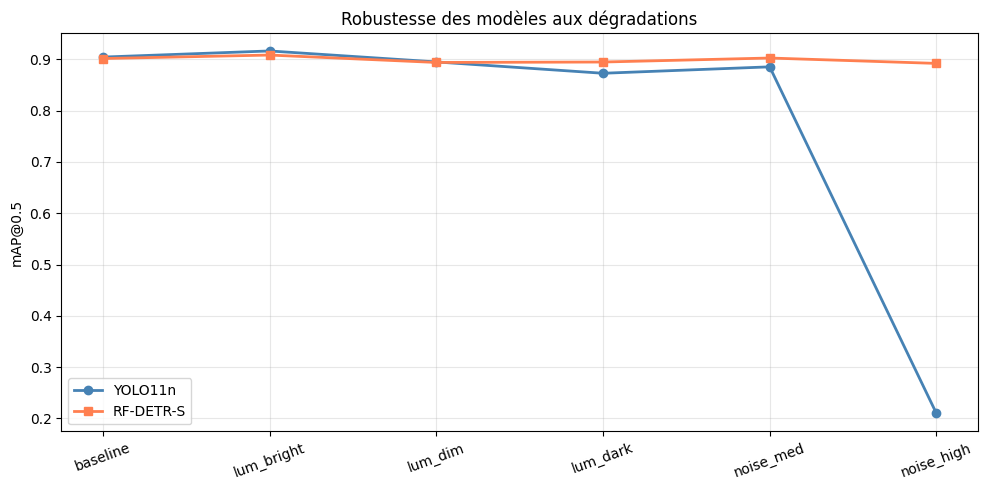

In [29]:
# Figure : courbe de robustesse
fig, ax = plt.subplots(figsize=(10, 5))
conditions_order = ['baseline', 'lum_bright', 'lum_dim', 'lum_dark', 'noise_med', 'noise_high']
y_vals = [yolo_robust[c]['mAP50'] for c in conditions_order if c in yolo_robust]
r_vals = [rfdetr_robust[c]['mAP50'] for c in conditions_order if c in rfdetr_robust]
x = list(range(len(conditions_order)))
ax.plot(x, y_vals, marker='o', label='YOLO11n', color='steelblue', linewidth=2)
ax.plot(x, r_vals, marker='s', label='RF-DETR-S', color='coral', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(conditions_order, rotation=20)
ax.set_ylabel('mAP@0.5')
ax.set_title('Robustesse des modèles aux dégradations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Téléchargement des résultats

In [30]:
import json

all_results = {
    'baseline': {'YOLO11n': yolo_summary, 'RF-DETR-S': rfdetr_summary},
    'robustness': {'YOLO11n': yolo_robust, 'RF-DETR-S': rfdetr_robust},
}
with open('all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

from google.colab import files
for f in ['all_results.json', 'comparison_summary.csv', 'robustness_summary.csv',
          'fig_class_distribution.png', 'fig_samples_grid.png',
          'fig_comparison_metrics.png', 'fig_robustness.png']:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>